# 03 · Modelo baseline

Modelo base con las 77 variables seleccionadas en el EDA. Validación temporal: entrena con 2023-08 a 2023-11 y evalúa en 2023-12, que simula el salto a enero. Luego reentrena con los 5 meses, califica el test y escribe los archivos de entrega.

1. Datos · 2. Validación temporal · 3. Modelo base · 4. Umbral · 5. Importancia · 6. Modelo final y archivos para Kaggle · 7. Registro en MLflow

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightgbm as lgb
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 50)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"; OUT = ROOT / "outputs"; OUT.mkdir(exist_ok=True)

C_BLUE, C_ORANGE, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY,
                     "axes.grid": True, "grid.color": "#ececea", "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})
SEED = 42

import sys; sys.path.insert(0, str(ROOT / "src"))
from tracking import grupo, registrar_final, registrar_kaggle, resumen

## 1. Datos

Train y test construidos en el notebook 01; lista de 77 variables del EDA. Conteo de categóricas y numéricas.

In [2]:
train = pd.read_parquet(DATA / "train.parquet")
test = pd.read_parquet(DATA / "test.parquet")
FEATS = pd.read_csv(DATA / "features_seleccionadas.csv").feature.tolist()
TARGET = "var_rpta_alt"

CAT = [c for c in FEATS if str(train[c].dtype) == "category"]
NUM = [c for c in FEATS if c not in CAT]
for c in CAT:  # mismas categorías en train y test
    cats = pd.api.types.union_categoricals([train[c], test[c]]).categories
    train[c] = pd.Categorical(train[c], categories=cats); test[c] = pd.Categorical(test[c], categories=cats)

print(f"train: {train.shape[0]:,} filas | test: {test.shape[0]:,} filas")
print(f"Variables: {len(FEATS)} = {len(NUM)} numéricas + {len(CAT)} categóricas")
print("Categóricas:", CAT)
print("\nFilas por mes en train:", train.fecha_var_rpta_alt.value_counts().sort_index().to_dict())

train: 568,251 filas | test: 112,549 filas
Variables: 77 = 62 numéricas + 15 categóricas
Categóricas: ['pag_marca_pago_t1', 'obl_producto', 'obl_aplicativo', 'obl_segmento', 'cli_genero_cli', 'cli_estado_civil', 'cli_ocup', 'cli_declarante', 'cli_segm', 'cli_subsegm', 'cli_region_of', 'cli_cli_actualizado', 'lag_desc_alternativa1_ult', 'lag_alter_posible1_2_ult', 'lag_alternativa_aplicada_agr_ult']

Filas por mes en train: {202308: 113531, 202309: 121185, 202310: 115923, 202311: 117146, 202312: 100466}


## 2. Validación temporal

Entrenamiento: 2023-08 a 2023-11 (467 k filas). Validación: 2023-12 (100 k filas). Diciembre nunca se usa para ajustar el modelo, solo para medir.

In [3]:
m_tr = train.fecha_var_rpta_alt <= 202311
m_va = train.fecha_var_rpta_alt == 202312
X_tr, y_tr = train.loc[m_tr, FEATS], train.loc[m_tr, TARGET]
X_va, y_va = train.loc[m_va, FEATS], train.loc[m_va, TARGET]
print(f"train: {len(X_tr):,} filas, tasa {y_tr.mean():.3f} | validación: {len(X_va):,} filas, tasa {y_va.mean():.3f}")

train: 467,785 filas, tasa 0.483 | validación: 100,466 filas, tasa 0.468


## 3. Modelo base

LightGBM con parámetros conservadores, sin ajuste. Maneja nulos y categóricas de forma nativa, así que no se imputa ni se codifica nada.

In [4]:
PARAMS = dict(objective="binary", learning_rate=0.05, n_estimators=600, num_leaves=63, min_child_samples=200,
              subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0, random_state=SEED, verbose=-1)

modelo = lgb.LGBMClassifier(**PARAMS)
modelo.fit(X_tr, y_tr, categorical_feature=CAT)
p_va = modelo.predict_proba(X_va)[:, 1]

AUC_VAL = roc_auc_score(y_va, p_va); F1_05 = f1_score(y_va, p_va >= 0.5)
print(f"AUC en diciembre: {AUC_VAL:.4f}")
print(f"F1 en diciembre con umbral 0,5: {f1_score(y_va, p_va >= 0.5):.4f}")
print(f"F1 si se predice todo 1 (benchmark de Kaggle): {f1_score(y_va, np.ones(len(y_va))):.4f}")

AUC en diciembre: 0.7589
F1 en diciembre con umbral 0,5: 0.6593
F1 si se predice todo 1 (benchmark de Kaggle): 0.6378


## 4. Umbral

F1 en diciembre para cada umbral de probabilidad entre 0,20 y 0,80. Se elige el que maximiza F1.

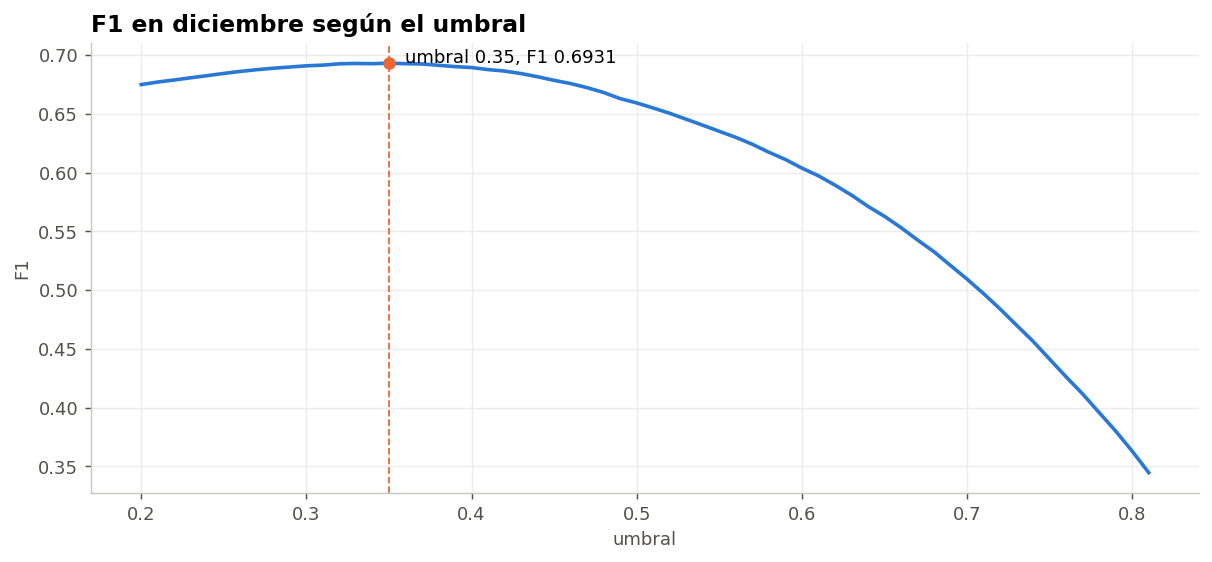

Umbral elegido: 0.35 | F1: 0.6931 | precisión: 0.5980 | recall: 0.8242 | % predicho 1: 0.645


In [5]:
umbrales = np.arange(0.20, 0.81, 0.01)
f1s = np.array([f1_score(y_va, p_va >= u) for u in umbrales])
UMBRAL = float(umbrales[f1s.argmax()]); F1_BEST = f1s.max()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(umbrales, f1s, color=C_BLUE, lw=2); ax.axvline(UMBRAL, color=C_ORANGE, ls="--", lw=1)
ax.scatter([UMBRAL], [F1_BEST], color=C_ORANGE, zorder=3); ax.text(UMBRAL + 0.01, F1_BEST, f"umbral {UMBRAL:.2f}, F1 {F1_BEST:.4f}", fontsize=10)
ax.set_xlabel("umbral"); ax.set_ylabel("F1"); ax.set_title("F1 en diciembre según el umbral"); fig_umbral = fig; plt.show()

pred = p_va >= UMBRAL
print(f"Umbral elegido: {UMBRAL:.2f} | F1: {F1_BEST:.4f} | precisión: {precision_score(y_va, pred):.4f} | recall: {recall_score(y_va, pred):.4f} | % predicho 1: {pred.mean():.3f}")

**Lectura.** El umbral se fija con diciembre y se aplica sin cambios al test. F1 es sensible al umbral, por eso no se deja en 0,5.

## 5. Importancia

Ganancia acumulada por variable en el modelo (las 25 mayores).

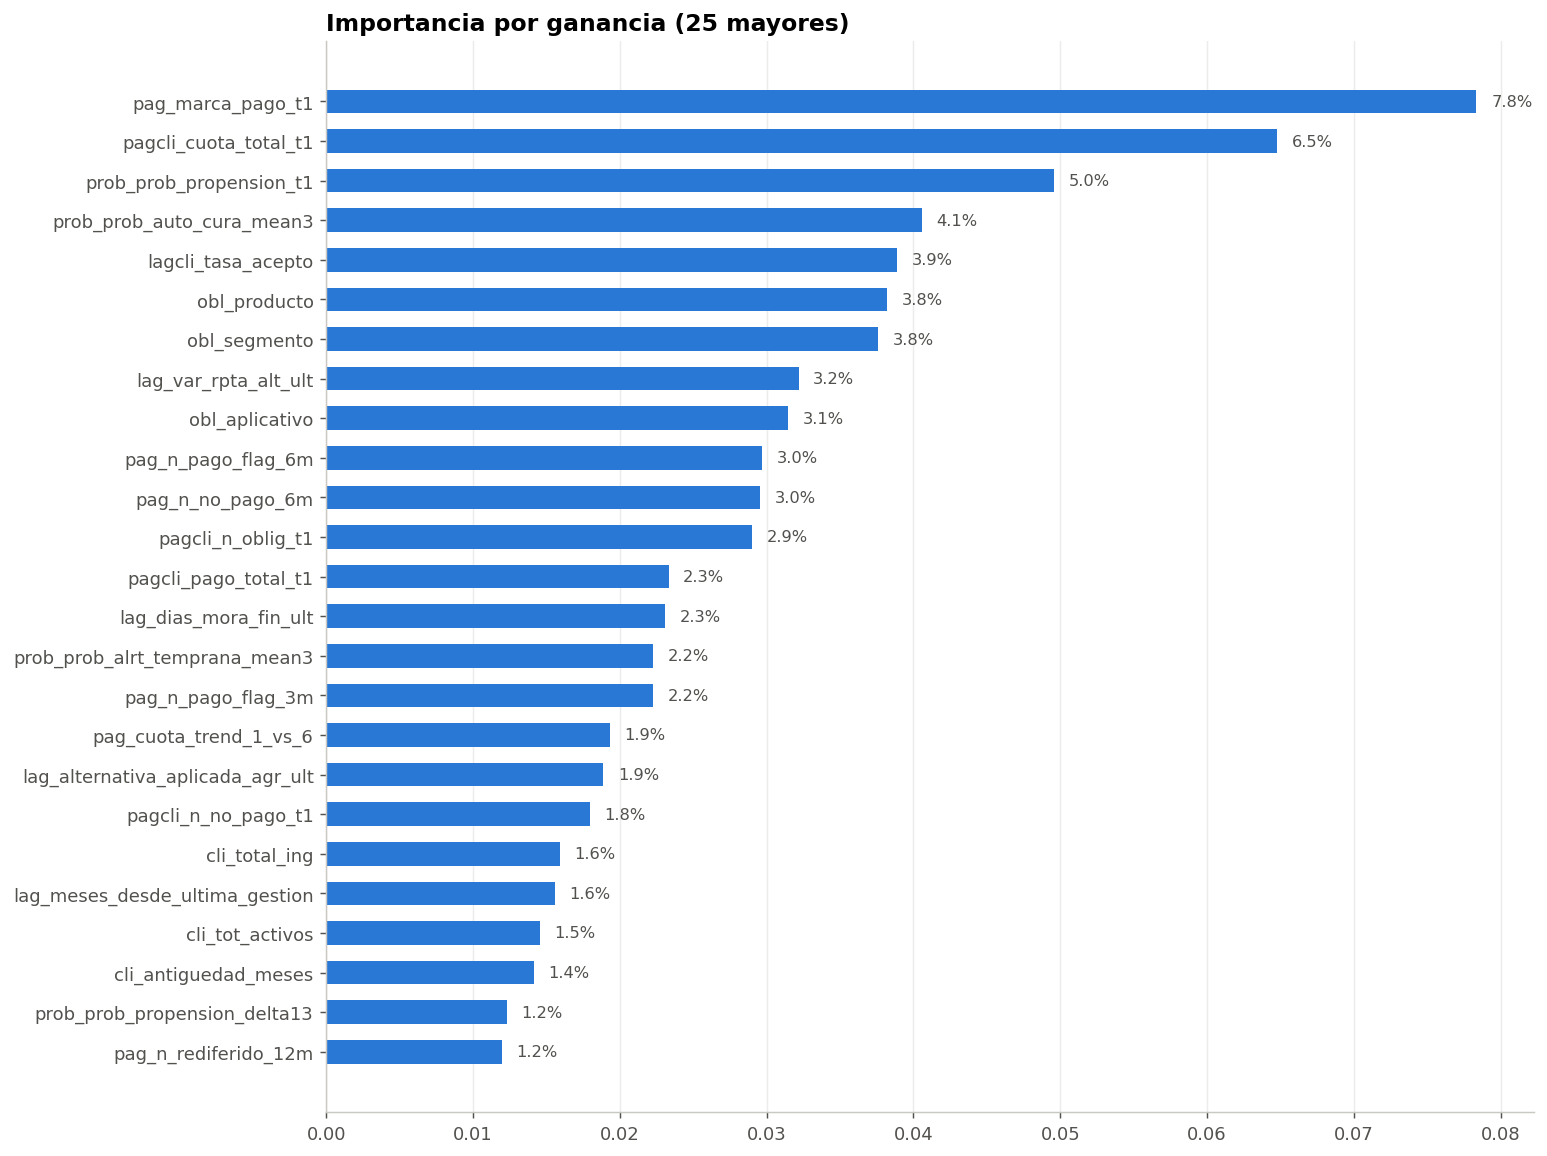

Bloques por importancia acumulada: {'pag': 0.283, 'prob': 0.173, 'pagcli': 0.137, 'cli': 0.124, 'lag': 0.123, 'obl': 0.107, 'lagcli': 0.052}


In [6]:
imp = pd.Series(modelo.booster_.feature_importance("gain"), index=FEATS).sort_values(ascending=False)
imp = imp / imp.sum()
d = imp.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(d.index, d.values, color=C_BLUE, height=0.6)
for yv, v in zip(d.index, d.values): ax.text(v + 0.001, yv, f"{v:.1%}", va="center", fontsize=9, color=C_MUTED)
ax.set_title("Importancia por ganancia (25 mayores)"); ax.grid(axis="y", visible=False); plt.tight_layout(); fig_imp = fig; plt.show()
print("Bloques por importancia acumulada:", imp.groupby(imp.index.str.split("_").str[0]).sum().sort_values(ascending=False).round(3).to_dict())

## 6. Modelo final y archivos para Kaggle

Reentrena con los 5 meses (mismos parámetros), califica el test con el umbral elegido y escribe dos archivos en `outputs/`: `submission.csv` (ID, var_rpta_alt) para Kaggle y `resultado_prueba.csv` (ID, var_rpta_alt, Prob_uno) para la entrega por correo. Orden igual al `sample_submission`.

In [7]:
modelo_final = lgb.LGBMClassifier(**PARAMS)
modelo_final.fit(train[FEATS], train[TARGET], categorical_feature=CAT)
p_te = modelo_final.predict_proba(test[FEATS])[:, 1]

ss = pd.read_csv(ROOT / "data" / "sample_submission.csv", usecols=["ID"])
res = pd.DataFrame({"ID": test.ID.astype(str), "Prob_uno": p_te})
res["var_rpta_alt"] = (res.Prob_uno >= UMBRAL).astype(int)
res = ss.merge(res, on="ID", how="left")
assert res.Prob_uno.notna().all() and len(res) == len(ss)

res[["ID", "var_rpta_alt"]].to_csv(OUT / "submission.csv", index=False)
res[["ID", "var_rpta_alt", "Prob_uno"]].round({"Prob_uno": 5}).to_csv(OUT / "resultado_prueba.csv", index=False, encoding="utf-8")
modelo_final.booster_.save_model(str(ROOT / "models" / "lgbm_base.txt"))

print(f"submission.csv: {len(res):,} filas | % predicho 1: {res.var_rpta_alt.mean():.3f} | prob media: {res.Prob_uno.mean():.3f}")
res.head()

submission.csv: 112,549 filas | % predicho 1: 0.612 | prob media: 0.451


,ID,Prob_uno,var_rpta_alt
0,243031#516680#563662,0.886278,1
1,401665#347465#733256,0.088805,0
2,391362#511160#569182,0.094489,0
3,169789#441265#639051,0.633633,1
4,341343#76559#1028512,0.311728,0


## 7. Registro en MLflow

Todo el proyecto va en un solo experimento de MLflow (`opciones_pago`). Este notebook crea el grupo `03_lightgbm_baseline` con un run `final`: parámetros, métricas en diciembre, umbral, lista de variables, las dos figuras y el modelo. Se adjunta el F1 público del primer envío a Kaggle (0,70694). Interfaz: `python src/mlflow_ui.py`.

In [8]:
metricas = {"auc_val": AUC_VAL, "f1_val_umbral_05": F1_05, "f1_val": F1_BEST, "precision_val": precision_score(y_va, pred),
            "recall_val": recall_score(y_va, pred), "pct_pred_1_val": pred.mean(), "pct_pred_1_oot": res.var_rpta_alt.mean()}
with grupo("03_lightgbm_baseline", notebook="03_modelo_baseline", modelo="lightgbm", validacion="temporal_dic2023", particion="train 2023-08..11 / val 2023-12"):
    run_id = registrar_final(PARAMS, metricas, UMBRAL, FEATS, modelo=modelo_final, flavor="lightgbm", ruta_modelo=ROOT / "models" / "lgbm_base.txt",
                             figuras={"f1_vs_umbral": fig_umbral, "importancia": fig_imp})
registrar_kaggle(run_id, 0.70694, submission_id=56152634)
print("run_id:", run_id)
resumen("final")

run_id: d13aad2810ff49d9b21c5589312bc5f7


,grupo,run,auc_val,f1_kaggle_publico,f1_val,f1_val_umbral_05,pct_pred_1_oot,pct_pred_1_val,precision_val,recall_val,umbral,n_features,start_time
0,03_lightgbm_baseline,final,0.758862,0.70694,0.693114,0.659282,0.611893,0.645273,0.598029,0.824153,0.35,77,2026-09-10 23:40:37.709000+00:00


Subir a Kaggle desde la raíz del proyecto:

```
python -m kaggle competitions submit prueba-analitica-modelo-opciones-de-pago-season-3 -f outputs/submission.csv -m "lgbm base, 77 vars"
python -m kaggle competitions submissions prueba-analitica-modelo-opciones-de-pago-season-3
```